In [1]:
import numpy as np
import gamry_parser
import glob
from pathlib import Path
import os
import re
from scipy.optimize import differential_evolution
from impedance.models.circuits import CustomCircuit
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import ScalarFormatter
import impedance.models.circuits.fitting as fitting


In [2]:
main_dir = Path(r"C:\Users\Alexa\Desktop\PEA\EIS_data\BTA")
patterns = ['*_168H.DTA', '*_72H.DTA', '*_48H.DTA']
file_list = []

for p in patterns:
    file_list.extend(list(main_dir.rglob(p)))
file_list.sort(key=lambda x: int(re.search(r'(\d+)H', x.name).group(1)))
    
all_datasets = []

for filename in file_list:
    parser = gamry_parser.GamryParser()
    parser.load(filename)
    data = parser.curves[0]
    eis_data = {
        'name': filename.stem,
        'Zreal':data['Zreal'].values,
        'Zimag':-data['Zimag'].values,
        'Zmod':data['Zmod'].values,
        'Zphz':data['Zphz'].values,
        'Z_data': data['Zreal'].values + 1j * data['Zimag'].values,
        'Freq':data['Freq'].values
    }

    eis_fit = {
        'circuit':None,
        'Z_fit':None,
        'Freq':data['Freq'].values,
        'chi_sq': None
    }
    
    all_datasets.append({"eis_data":eis_data,"eis_fit":eis_fit})

print(all_datasets[0]['eis_data']['name'])

Cauvel_3_BTA_48H


In [3]:
circuit_string = 'R1-p(R2-p(R3-Wo3,CPE3),CPE2)'
#R1,R2,R3,Ws1_0, Ws1_1, CPE3_Q, CPE3_n,CPE2_Q,CPE2_n
bounds = [(1e-3, 1e3),
          (1, 1e8), 
          (1, 1e8),
          (1e-3, 1e4),
          (1, 1e8),
          (1e-9, 1e-3), 
          (0.5,1), 
          (1e-9, 1e-3), 
          (0.5,1),
         ]

In [4]:
def parameter_guesser(all_datasets,circuit_string,bounds):
    for i, dataset in enumerate(all_datasets):

        freq = dataset['eis_data']['Freq']
        z_data = dataset['eis_data']['Z_data']
        
        def objective_function(params):
            try:
                circuit = CustomCircuit(circuit_string, initial_guess=params)
                z_fit = circuit.predict(freq)
                res = np.sum(np.abs(z_data - z_fit)**2/np.abs(z_data))
                return res
            except:
                return 1e15

        de_parameters = differential_evolution(
            objective_function, 
            bounds,
            strategy='best1bin',
            popsize=10,
            tol=0.01,
            mutation=(0.5, 1),
            recombination=0.7
            )
        
        lower_bounds, upper_bounds = zip(*bounds)
        fit_bounds = (list(lower_bounds), list(upper_bounds))
        circuit= CustomCircuit(circuit_string, initial_guess=de_parameters.x)

        circuit.fit(
            freq, 
            z_data,
            bounds=fit_bounds,           # Define your boundaries
            weight_by_modulus=True,  # Weighting by |Z|
            global_opt=False          # Use global optimization (Basinhopping)
            )

        z_fit = circuit.predict(dataset['eis_data']['Freq'])

        def chi_squared(z_data, z_fit, n_params):
            n_points = len(z_data)
            degrees_of_freedom = n_points - n_params
            
            weight = np.abs(z_data)**2
            residuals = (np.abs(z_data - z_fit)**2) / weight
            
            chi_sq = np.sum(residuals) / degrees_of_freedom
            return chi_sq

        chi_result = chi_squared(z_data, z_fit, 10)
            
        all_datasets[i]['eis_fit']['circuit'] = circuit
        all_datasets[i]['eis_fit']['Z_fit'] = z_fit
        all_datasets[i]['eis_fit']['chi_sq'] = chi_result
        
    return all_datasets
    

In [5]:
all_datasets = parameter_guesser(all_datasets, circuit_string, bounds)

C:\pea\code\parameter_guesser\.venv\Lib\site-packages\impedance\models\circuits\circuits.py:145: UserWarning: Simulating circuit based on initial parameters
  warnings.warn("Simulating circuit based on initial parameters")
C:\pea\code\parameter_guesser\.venv\Lib\site-packages\impedance\models\circuits\elements.py:170: RuntimeWarning: overflow encountered in tanh
  Z = Z0 / (np.sqrt(1j * omega * tau) * np.tanh(np.sqrt(1j * omega * tau)))


In [7]:
print(all_datasets[0]['eis_fit']['Z_fit'])

[   73.79864082-1.97148315e+00j    73.96105262-2.33439206e+00j
    74.15247943-2.76211813e+00j    74.3784373 -3.26697726e+00j
    74.64652951-3.86594445e+00j    74.96643576-4.58062690e+00j
    75.34020287-5.41557199e+00j    75.78318162-6.40503649e+00j
    76.31104145-7.58396912e+00j    76.93761314-8.98318691e+00j
    77.65476762-1.05844486e+01j    78.51996167-1.25159126e+01j
    79.5793    -1.48802792e+01j    80.81617129-1.76401816e+01j
    82.26725693-2.08771054e+01j    83.9702732 -2.46746774e+01j
    85.96868757-2.91291291e+01j    88.54907137-3.48778649e+01j
    91.3560733 -4.11277397e+01j    94.58861927-4.83202877e+01j
    98.70878881-5.74803794e+01j   103.34525223-6.77783428e+01j
   109.16618139-8.06921947e+01j   115.41617687-9.45395208e+01j
   123.57871991-1.12595624e+02j   133.01138113-1.33421123e+02j
   143.73219618-1.57038566e+02j   157.39617456-1.87059879e+02j
   172.74664797-2.20680737e+02j   191.39694615-2.61379473e+02j
   212.63552254-3.07528651e+02j   239.81223917-3.662773

In [8]:
def plotter(all_datasets):
    for dataset in all_datasets:
        name = dataset['eis_data']['name']
        freq = dataset['eis_data']['Freq']
        z_data = dataset['eis_data']['Z_data']
        z_fit = dataset['eis_fit']['Z_fit']

        fig = plt.figure(figsize=(12, 10))
        gs = gridspec.GridSpec(2, 2, height_ratios=[1.5, 1.2], width_ratios=[1, 1])
        
        ax1 = fig.add_subplot(gs[0, :]) 
        
        ax1.plot(z_data.real, -z_data.imag, 'o', label='Experimental Data', markersize=5, alpha=0.6)
        ax1.plot(z_fit.real, -z_fit.imag, 'r-', label='10-Parameter Fit', linewidth=2)
        
        ax1.set_aspect('equal', adjustable='box')
        limit_max = max(z_data.real.max(), -z_data.imag.max())
        limit_min = min(z_data.real.min(), -z_data.imag.min())
        ax1.set_ylim(1.1*limit_min, 1.1*limit_max)
        ax1.set_xlim(1.1*limit_min, 1.1*limit_max)
        
        ax1.set_xlabel(r'Z$_{real}$ ($\Omega$/cm$^2$)', fontsize=12)
        ax1.set_ylabel(r'-Z$_{imag}$ ($\Omega$/cm$^2$)', fontsize=12)
        ax1.set_title("Nyquist Plot")
        ax1.legend()
        ax1.ticklabel_format(style='sci', axis='both',scilimits=(0,0), useMathText=True)
        ax1.grid(True, linestyle='--', alpha=0.6)
        
        ax2 = fig.add_subplot(gs[1, 0]) 
        
        ax2.loglog(freq, abs(z_data), 'o', markersize=4, alpha=0.6)
        ax2.loglog(freq, abs(z_fit), 'r-', linewidth=1.5)
        ax2.set_xlabel("Frequency (Hz)")
        ax2.set_ylabel(r'Z$_{mod}$ ($\Omega$/cm$^2$)')
        ax2.set_title("Bode Modulus")
        ax2.grid(True, which="both", linestyle='--', alpha=0.4)
        
        ax3 = fig.add_subplot(gs[1, 1]) 
        
        ax3.semilogx(freq, np.angle(z_data, deg=True), 'o', markersize=4, alpha=0.6)
        ax3.semilogx(freq, np.angle(z_fit, deg=True), 'r-', linewidth=1.5)
        ax3.set_xlabel("Frequency (Hz)")
        ax3.set_ylabel(r"Phase Angle (deg)")
        ax3.set_title("Bode Phase")
        ax3.grid(True, which="both", linestyle='--', alpha=0.4)
        
        plt.tight_layout()
        plt.savefig(f"plots_{name}.pdf")
        plt.show()
    return None

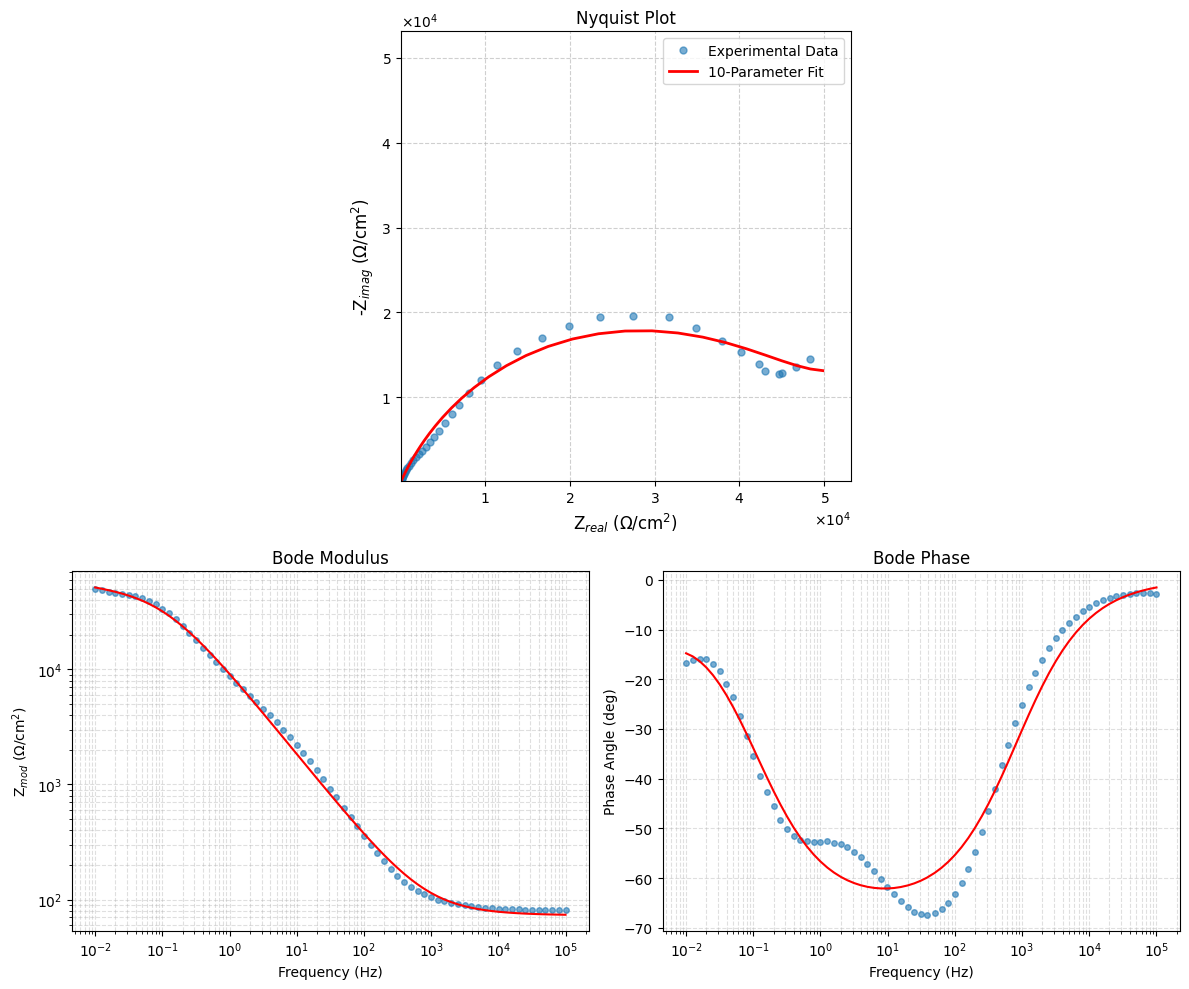

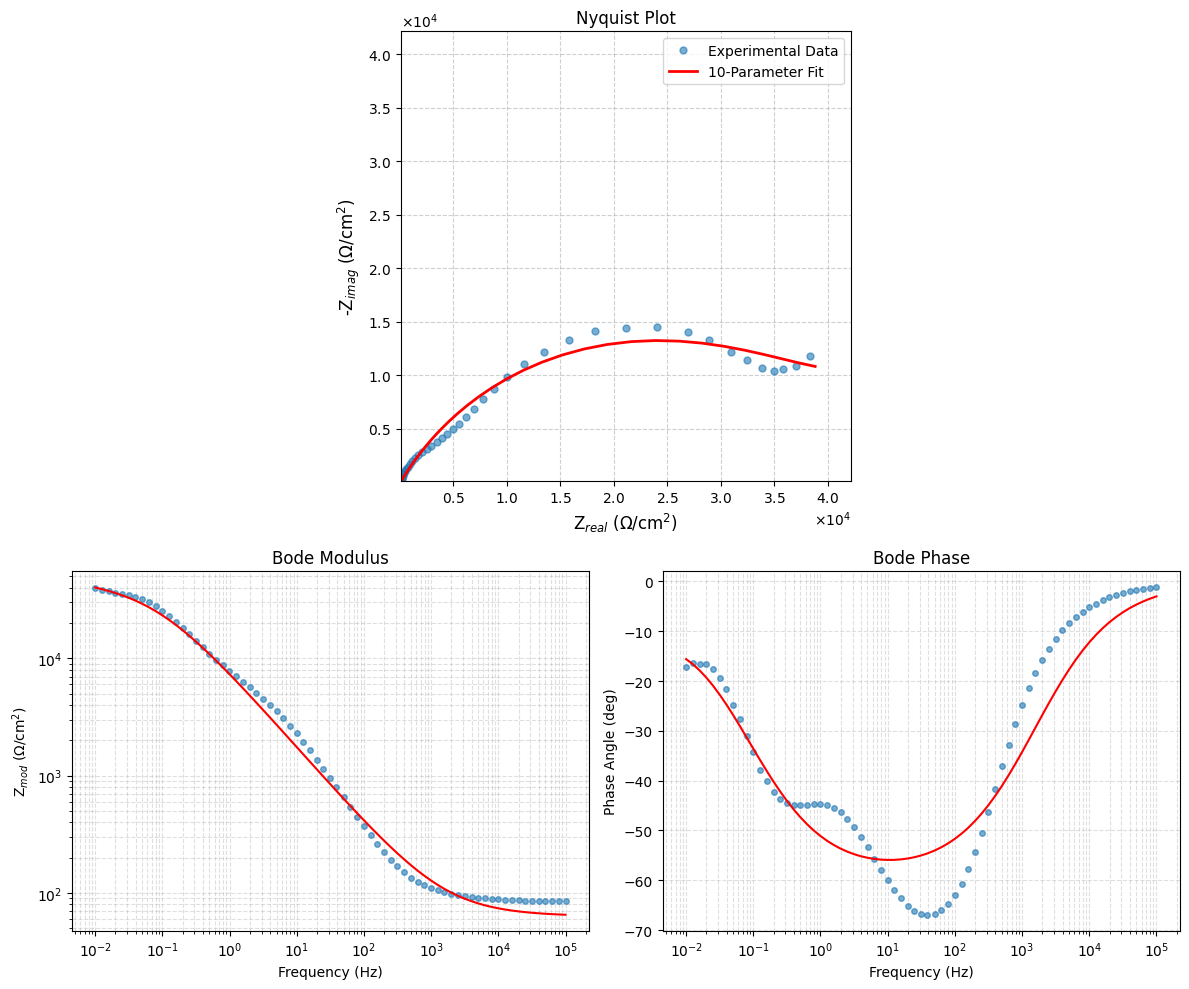

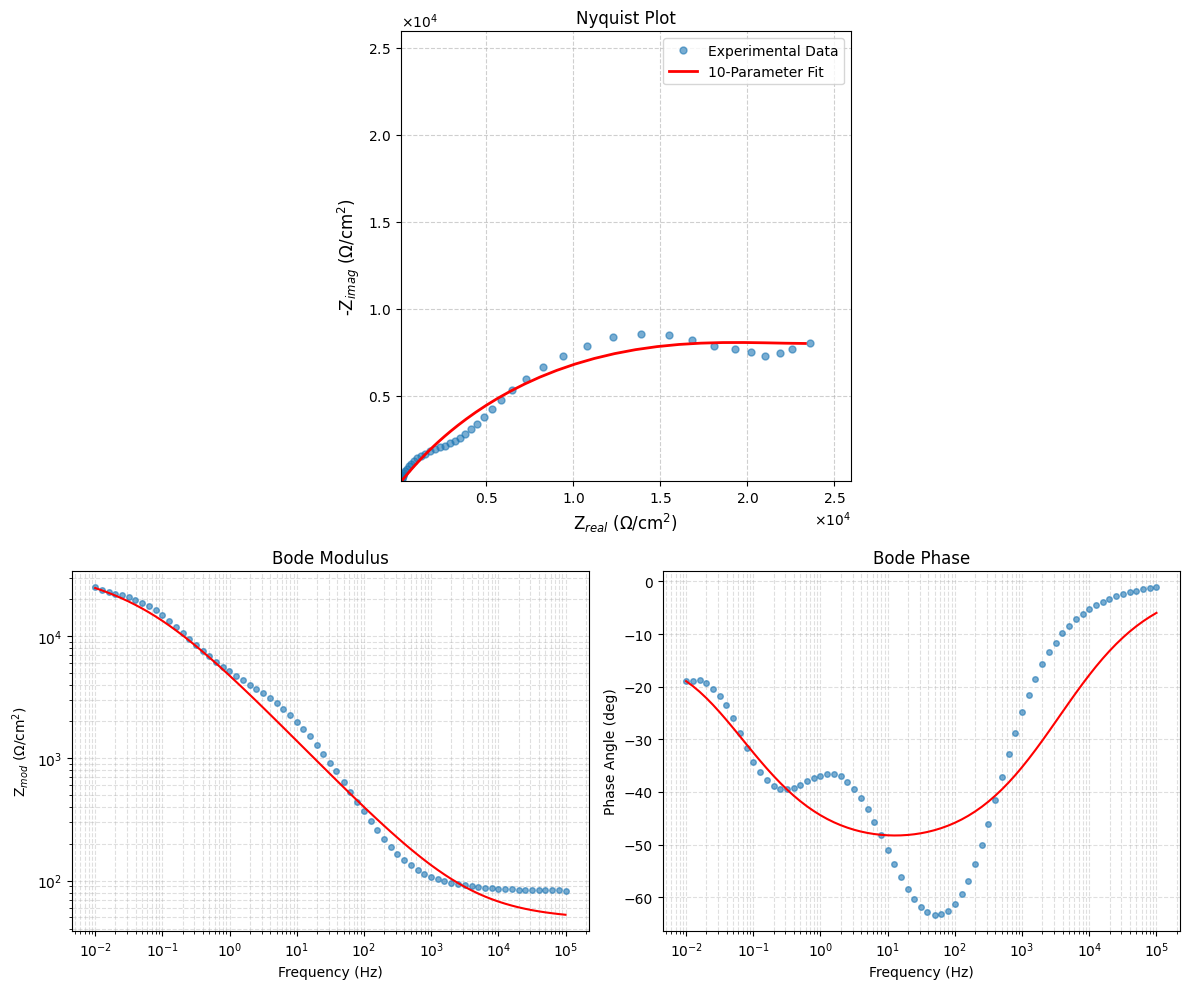

In [9]:
plotter(all_datasets)

In [19]:
print(all_datasets[0]['eis_fit']['circuit'])
print(all_datasets[0]['eis_data']['name'])


Circuit string: R1-p(R2-p(R3-Wo3,CPE3),CPE2)
Fit: True

Initial guesses:
     R1 = 7.29e+01 [Ohm]
     R2 = 5.38e+04 [Ohm]
     R3 = 4.88e+07 [Ohm]
  Wo3_0 = 6.48e+03 [Ohm]
  Wo3_1 = 8.09e+07 [sec]
  CPE3_0 = 9.96e-04 [Ohm^-1 sec^a]
  CPE3_1 = 6.85e-01 []
  CPE2_0 = 2.59e-05 [Ohm^-1 sec^a]
  CPE2_1 = 7.32e-01 []

Fit parameters:
     R1 = 7.29e+01  (+/- 1.55e+00) [Ohm]
     R2 = 5.38e+04  (+/- 4.84e+03) [Ohm]
     R3 = 4.88e+07  (+/- 2.55e-05) [Ohm]
  Wo3_0 = 6.48e+03  (+/- 5.47e-07) [Ohm]
  Wo3_1 = 8.09e+07  (+/- 1.08e-11) [sec]
  CPE3_0 = 9.96e-04  (+/- 1.92e-03) [Ohm^-1 sec^a]
  CPE3_1 = 6.85e-01  (+/- 5.95e-01) []
  CPE2_0 = 2.63e-05  (+/- 8.86e-07) [Ohm^-1 sec^a]
  CPE2_1 = 7.32e-01  (+/- 6.16e-03) []

Cauvel_3_BTA_48H


In [36]:

def generate_combined_eis_report(all_datasets, circuit_string):
    # 1. Extract parameter info from first dataset
    first_circuit_text = str(all_datasets[0]['eis_fit']['circuit'])
    # Pattern to capture: Name = Value (+/- Error) [Unit]
    param_pattern = r"([A-Z0-9_]+)\s+=\s+([0-9.e+-]+)\s+\(\+/-\s+([0-9.e+-]+)\)\s+\[(.*?)\]"
    
    if "Fit parameters:" in first_circuit_text:
        fit_section = first_circuit_text.split("Fit parameters:")[1]
        matches = re.findall(param_pattern, fit_section)

    # 2. Build Header
    header = r"\textbf{Element} & \textbf{Unit}"
    column_setup = "|l|c|" 
    for dataset in all_datasets:
        clean_name = dataset['eis_data']['name'].replace("_", "\\_")
        header += f" & \\textbf{{{clean_name}}}"
        column_setup += "c|"

    # 3. Build Table Rows
    table_rows = ""
    for p_name, _, _, p_unit in matches:
        # --- FIXED MAPPING FOR ELEMENT NAMES ---
        # Handles R, CPE (Q/n), and Warburg (R/tau)
        if "CPE" in p_name:
            display_name = p_name.replace("_0", "_Q").replace("_1", "_n")
        elif "Wo" in p_name:
            if p_name.endswith("_0"):
                display_name = "W_{R}"
            elif p_name.endswith("_1"):
                display_name = r"W_{\tau}"
            else:
                display_name = p_name
        else:
            display_name = p_name
        
        clean_p_name = display_name.replace("_", "\\_")
        
        # Unit Formatting
        clean_unit = p_unit.replace("Ohm", r"$\Omega$").replace("^-1", r"$^{-1}$").replace("^a", r"$^{a}$")
        if not clean_unit.strip() or clean_unit == "[]": clean_unit = "-"
            
        row_content = f"{clean_p_name} & {clean_unit}"
        
        # 4. Values and Errors
        for dataset in all_datasets:
            circ_text = str(dataset['eis_fit']['circuit'])
            val_match = re.search(rf"{p_name}\s+=\s+([0-9.e+-]+)\s+\(\+/-\s+([0-9.e+-]+)\)", circ_text)
            
            if val_match:
                val, err = val_match.groups()
                row_content += f" & {float(val):.2e} $\pm$ {float(err):.1e}"
            else:
                row_content += " & N/A"
        
        table_rows += f"        {row_content} \\\\ \hline \n"

    # 5. Chi-Squared Row
    chi_row = r"\textbf{$\chi^2$} & - "
    for dataset in all_datasets:
        chi = dataset['eis_fit']['chi_sq']
        chi_row += f" & {chi:.4e}"
    table_rows += f"        {chi_row} \\\\ \hline \n"

    # 6. Build Plot Sections with distinct Titles
    plot_sections = ""
    for dataset in all_datasets:
        data_name = dataset['eis_data']['name']
        hour_label = re.search(r'(\d+H)', data_name).group(1) if re.search(r'(\d+H)', data_name) else data_name
        plot_filename = f"plots_{data_name.replace('.DTA', '')}.pdf"
        
        plot_sections += r"""
\begin{center}
    \section*{Analysis: """ + hour_label + r"""}
    \vspace{10pt}
    \includegraphics[width=0.7\textwidth]{""" + plot_filename + r"""}
    \captionof{figure}{EIS Data and Model Fit for """ + data_name.replace("_", "\\_") + r"""}
\end{center}
\newpage
"""

    # --- Construct LaTeX Document ---
    tex_content = r"""
\documentclass[10pt]{article}
\usepackage[utf8]{inputenc}
\usepackage{graphicx}
\usepackage{amsmath, amssymb}
\usepackage{geometry}
\usepackage{array}
\usepackage{caption}
\geometry{a4paper, margin=0.5in, landscape} 

\begin{document}

\section*{Comparative EIS Kinetics Report}
\textbf{Equivalent Circuit:} \texttt{""" + circuit_string.replace("_", "\\_") + r"""}

\begin{center}
    % If you have a circuit diagram PDF saved as circuit.pdf
    \includegraphics[width=0.4\textwidth]{circuit.png}
\end{center}

\renewcommand{\arraystretch}{1.6} % Wider rows
\begin{table}[h!]
    \centering
    \footnotesize
    \begin{tabular}{""" + column_setup + r"""}
        \hline
        """ + header + r""" \\ \hline
""" + table_rows + r"""
    \end{tabular}
    \caption{Refined parameters with calculated standard deviations across exposure duration.}
\end{table}

\newpage
""" + plot_sections + r"""

\end{document}
"""
    with open("EIS_Final_Kinetics_Report.tex", "w", encoding="utf-8") as f:
        f.write(tex_content)
    
generate_combined_eis_report(all_datasets, circuit_string)

<>:51: SyntaxWarning: invalid escape sequence '\p'
<>:55: SyntaxWarning: invalid escape sequence '\h'
<>:62: SyntaxWarning: invalid escape sequence '\h'
<>:51: SyntaxWarning: invalid escape sequence '\p'
<>:55: SyntaxWarning: invalid escape sequence '\h'
<>:62: SyntaxWarning: invalid escape sequence '\h'
C:\Users\Alexa\AppData\Local\Temp\ipykernel_13220\3927758177.py:51: SyntaxWarning: invalid escape sequence '\p'
  row_content += f" & {float(val):.2e} $\pm$ {float(err):.1e}"
C:\Users\Alexa\AppData\Local\Temp\ipykernel_13220\3927758177.py:55: SyntaxWarning: invalid escape sequence '\h'
  table_rows += f"        {row_content} \\\\ \hline \n"
C:\Users\Alexa\AppData\Local\Temp\ipykernel_13220\3927758177.py:62: SyntaxWarning: invalid escape sequence '\h'
  table_rows += f"        {chi_row} \\\\ \hline \n"


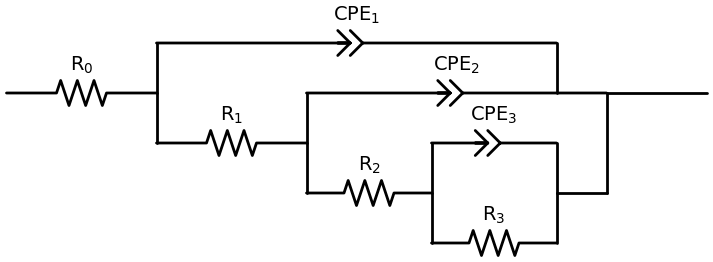

In [54]:
import schemdraw
import schemdraw.elements as elm

with schemdraw.Drawing() as d:
    d += elm.Resistor().right().label('R$_0$')
    d.push()
    d += elm.Line().up().length(1)
    d += elm.CPE().right().length(8).label('CPE$_1$')
    d += elm.Line().down().length(1)
    d.pop()
    d += elm.Line().down().length(1)
    d += elm.Resistor().right().label('R$_1$')
    d.push()
    d += elm.Line().up().length(1)
    d += elm.CPE().right().length(6).label('CPE$_2$')
    d.pop()
    d += elm.Line().down().length(1)
    d += elm.Resistor().right().length(2.5).label('R$_2$')
    d.push()
    d += elm.Line().up().length(1)
    d += elm.CPE().right().length(2.5).label('CPE$_3$')
    d += elm.Line().down().length(1)
    d.pop()
    d += elm.Line().down().length(1)
    d += elm.Resistor().right().length(2.5).label('R$_3$')
    d += elm.Line().up().length(1)
    d += elm.Line().right().length(1)
    d += elm.Line().up().length(2)
    d += elm.Line().right().length(2)
    d.save('circuit_3RC.png', dpi=300, transparent=True)
    
    
    